# Foodpanda Sales Forecasting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("E:\\Deep Learning\\Foodpanda\\dataset\\Foodpanda.csv")

date_cols = ["signup_date", "order_date", "last_order_date", "rating_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

text_cols = ["customer_id", "gender", "age", "city", "order_id",
             "restaurant_name", "dish_name", "category",
             "payment_method", "churned", "delivery_status"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["rating_status"] = np.where(df["rating"].isna(), "Not Rated", "Rated")
df["order_value"] = df["quantity"] * df["price"]
df = df.rename(columns={"age": "age_group"})

reference_date = df["last_order_date"].max()
df["tenure_days"] = (reference_date - df["signup_date"]).dt.days
df["recency_days"] = (reference_date - df["last_order_date"]).dt.days
df["order_month"] = df["order_date"].dt.month
df["order_year"] = df["order_date"].dt.year
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.day_name()

print("Shape:", df.shape)
df.head()

Shape: (6000, 28)


,customer_id,gender,age_group,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,rating_date,delivery_status,rating_status,order_value,tenure_days,recency_days,order_month,order_year,order_day,order_weekday
0,C5663,Male,Adult,Peshawar,2024-01-14,O9663,2023-08-23,McDonald's,Burger,Italian,...,2024-10-14,Cancelled,Not Rated,7391.35,585,33,8,2023,23,Wednesday
1,C2831,Male,Adult,Multan,2024-07-07,O6831,2023-08-23,KFC,Burger,Italian,...,2025-08-21,Delayed,Rated,2868.12,410,269,8,2023,23,Wednesday
2,C2851,Other,Senior,Multan,2025-06-20,O6851,2023-08-23,Pizza Hut,Fries,Italian,...,2024-09-19,Delayed,Rated,1765.02,62,103,8,2023,23,Wednesday
3,C1694,Female,Senior,Peshawar,2023-09-05,O5694,2023-08-23,Subway,Pizza,Dessert,...,2025-06-29,Delayed,Rated,925.20,716,28,8,2023,23,Wednesday
4,C4339,Other,Senior,Lahore,2023-12-29,O8339,2023-08-24,KFC,Sandwich,Dessert,...,2025-03-06,Cancelled,Not Rated,1156.69,601,243,8,2023,24,Thursday


In [3]:
sales_df = df.groupby("order_date")["order_value"].sum().reset_index()
sales_df = sales_df.sort_values("order_date")
sales_df.head()

,order_date,order_value
0,2023-08-23,12949.69
1,2023-08-24,25841.21
2,2023-08-25,19486.63
3,2023-08-26,34468.20
4,2023-08-27,13891.09


In [4]:
sales_df["lag_1"] = sales_df["order_value"].shift(1)
sales_df["lag_7"] = sales_df["order_value"].shift(7)
sales_df["rolling_mean_7"] = sales_df["order_value"].rolling(7).mean()

sales_df = sales_df.dropna().reset_index(drop=True)
sales_df.head()

,order_date,order_value,lag_1,lag_7,rolling_mean_7
0,2023-08-30,18950.68,11811.44,12949.69,19673.071429
1,2023-08-31,22616.82,18950.68,25841.21,19212.444286
2,2023-09-01,10195.99,22616.82,19486.63,17885.210000
3,2023-09-02,17233.47,10195.99,34468.20,15423.105714
4,2023-09-03,18384.94,17233.47,13891.09,16065.084286


In [5]:
train_size = int(len(sales_df) * 0.8)

train_data = sales_df[:train_size]
test_data = sales_df[train_size:]

X_train_s = train_data[["lag_1", "lag_7", "rolling_mean_7"]]
y_train_s = train_data["order_value"]

X_test_s = test_data[["lag_1", "lag_7", "rolling_mean_7"]]
y_test_s = test_data["order_value"]

In [6]:
sales_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
sales_model.fit(X_train_s, y_train_s)

y_pred_sales = sales_model.predict(X_test_s)

In [7]:
mae = mean_absolute_error(y_test_s, y_pred_sales)
rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_sales))
r2 = r2_score(y_test_s, y_pred_sales)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5230.846058506525
RMSE: 6683.533498482326
R2 Score: 0.12429231123016193


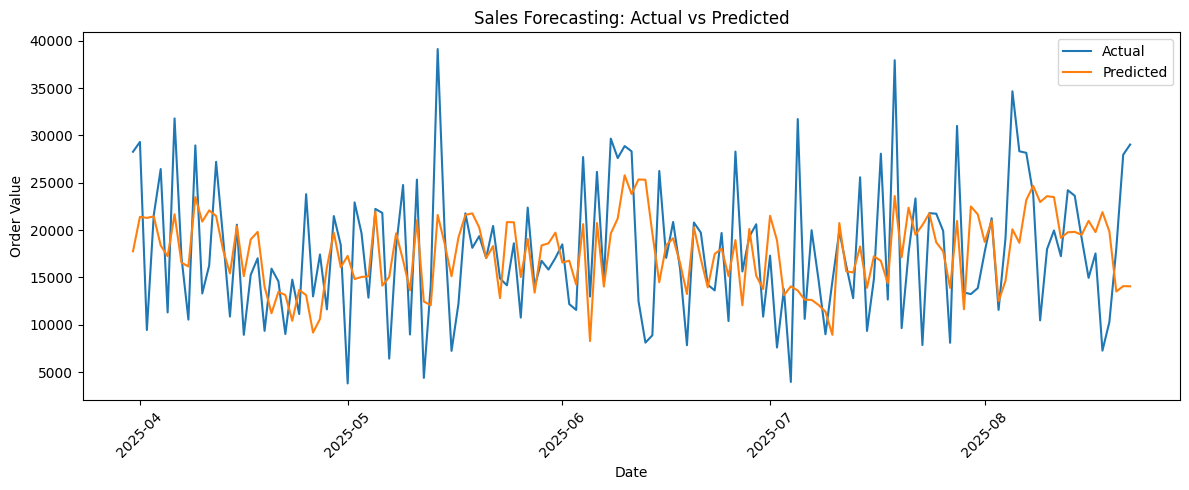

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(test_data["order_date"], y_test_s.values, label="Actual")
plt.plot(test_data["order_date"], y_pred_sales, label="Predicted")
plt.title("Sales Forecasting: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Order Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()